
notebook.ipynb
├── 01_setup.ipynb           # imports, paths, config (Abdelrahman owns)
├── 02_detection_demo.ipynb  # demonstrates detection module on 1 frame (Abdelrahman)
├── 03_court_mapping_demo.ipynb # demonstrates homography on 1 frame (Zyad)
├── 04_shot_detection_demo.ipynb # demonstrates make/miss logic on a clip (Ilias)
├── 05_full_pipeline.ipynb   # end-to-end on a real video (joint, last)
└── modules/
    ├── detection.py    (Abdelrahman)
    ├── court.py        (Zyad)
    ├── shots.py        (Ilias)
    └── pipeline.py     (Abdelrahman, written last)


# 1. Setup


In [5]:
%pip install ultralytics
%pip install supervision
%pip install inference

import os
import cv2
import numpy as np
import torch
from ultralytics import YOLO
import supervision as sv
from inference import get_model

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


# Data
There are 3 datasets to use for training on different tasks
1. Basketball and net detection
2. Court detection
3. player detection

The code below unzips all three and assigns them into subfolders


In [5]:
import zipfile, glob, os

for path in glob.glob('Data/*.zip'):
    name = os.path.splitext(os.path.basename(path))[0]
    out = os.path.join('Data', name)
    print(f'Extracting → {out}')
    with zipfile.ZipFile(path) as z:
        z.extractall(out)


# 2 detection demo  (abdo)

# 3 court vision mappign (CVM) (Zyad)


## Imports


In [4]:
import yaml
from pathlib import Path

## Dataset assignment

In [6]:


# This dataset is a KEYPOINT/POSE dataset (33 court keypoints per image),
# not plain object detection. data.yaml already contains kpt_shape: [33, 3]
# and flip_idx, so we just need to point train/val/test at absolute paths.

CVM_root = Path("Data/basketball-court-detection-2.v1-1.yolov8").resolve()
yaml_data_path = CVM_root / "data.yaml"

with open(yaml_data_path, "r") as f:
    yolo_config = yaml.safe_load(f)

yolo_config["path"]  = str(CVM_root)
yolo_config["train"] = str(CVM_root / "train" / "images")
yolo_config["val"]   = str(CVM_root / "valid" / "images")
yolo_config["test"]  = str(CVM_root / "test"  / "images")

# Write a working copy next to the notebook so Ultralytics can resolve paths
updated_yaml_path = Path("cvm_data.yaml").resolve()
with open(updated_yaml_path, "w") as f:
    yaml.safe_dump(yolo_config, f, sort_keys=False)

print("Updated data.yaml ->", updated_yaml_path)
print(f"  train: {yolo_config['train']}")
print(f"  val:   {yolo_config['val']}")
print(f"  test:  {yolo_config['test']}")
print(f"  nc:    {yolo_config['nc']}  names: {yolo_config['names']}")
print(f"  kpt_shape: {yolo_config.get('kpt_shape')}")


Updated data.yaml -> /Users/Zyad/Project-45-Basketball-2D-Mapping/cvm_data.yaml
  train: /Users/Zyad/Project-45-Basketball-2D-Mapping/Data/basketball-court-detection-2.v1-1.yolov8/train/images
  val:   /Users/Zyad/Project-45-Basketball-2D-Mapping/Data/basketball-court-detection-2.v1-1.yolov8/valid/images
  test:  /Users/Zyad/Project-45-Basketball-2D-Mapping/Data/basketball-court-detection-2.v1-1.yolov8/test/images
  nc:    1  names: ['court']
  kpt_shape: [33, 3]


## Model Training

In [7]:
from ultralytics import YOLO

# Pose variant of YOLO26n - required because this is a keypoint task.
# (Ultralytics auto-downloads weights on first use.)
Court_vision_model = YOLO("yolo26n-pose.pt")
Court_vision_model.info()


YOLO26n-pose summary: 363 layers, 3,679,464 parameters, 0 gradients, 10.3 GFLOPs


(363, 3679464, 0, 10.318528)

In [ ]:

CVM_results = Court_vision_model.train(
    data=str(updated_yaml_path),
    epochs=1,
    imgsz=640,
    batch=8,
    project="runs",
    name="CVM",
    exist_ok=True,
    deterministic=True,
    plots=True,
    patience=30,          # early-stop if no val improvement
    device=0 if torch.cuda.is_available() else "cpu",
)


YOLO26n-pose summary: 363 layers, 3,679,464 parameters, 0 gradients, 10.3 GFLOPs
Ultralytics 8.4.50 🚀 Python-3.12.7 torch-2.12.0 CPU (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/Zyad/Project-45-Basketball-2D-Mapping/cvm_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-pose.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=CVM, nb

### Single frame keypoint detection

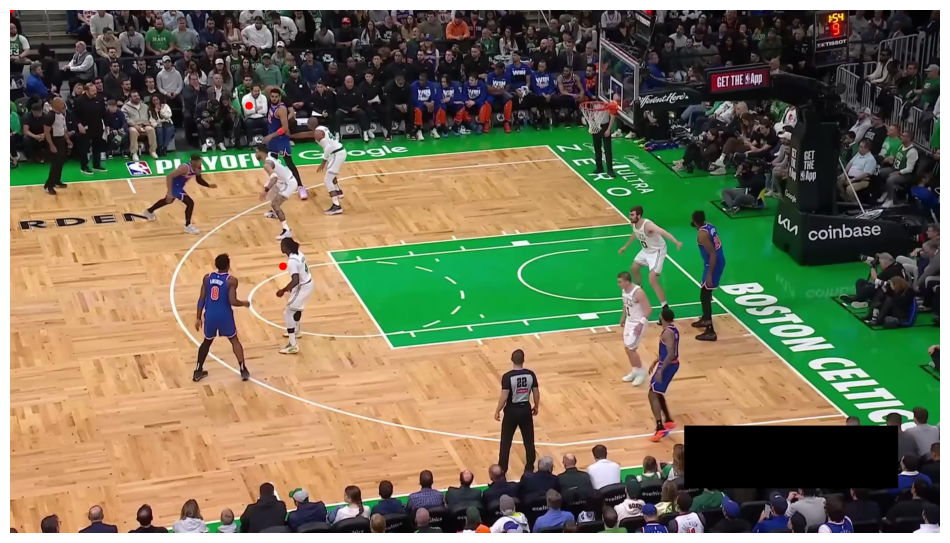

In [15]:
from ultralytics import YOLO
import supervision as sv
import numpy as np

CVM_model = YOLO("runs/pose/runs/CVM/weights/best.pt")

SOURCE_VIDEO_PATH = "Data/boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4"
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = CVM_model.predict(frame, conf=0.3, verbose=False)[0]
key_points = sv.KeyPoints.from_ultralytics(result)

# Keep only keypoints with per-vertex confidence > 0.5
 # Zero out low-confidence keypoints (VertexAnnotator skips (0, 0))
confidence_mask = key_points.confidence > 0.5
filtered_xy = np.where(confidence_mask[..., None], key_points.xy, 0)
key_points = sv.KeyPoints(xy=filtered_xy, confidence=key_points.confidence)

vertex_annotator = sv.VertexAnnotator(color=sv.Color.RED, radius=8)
annotated_frame = vertex_annotator.annotate(scene=frame.copy(), key_points=key_points)
sv.plot_image(annotated_frame)

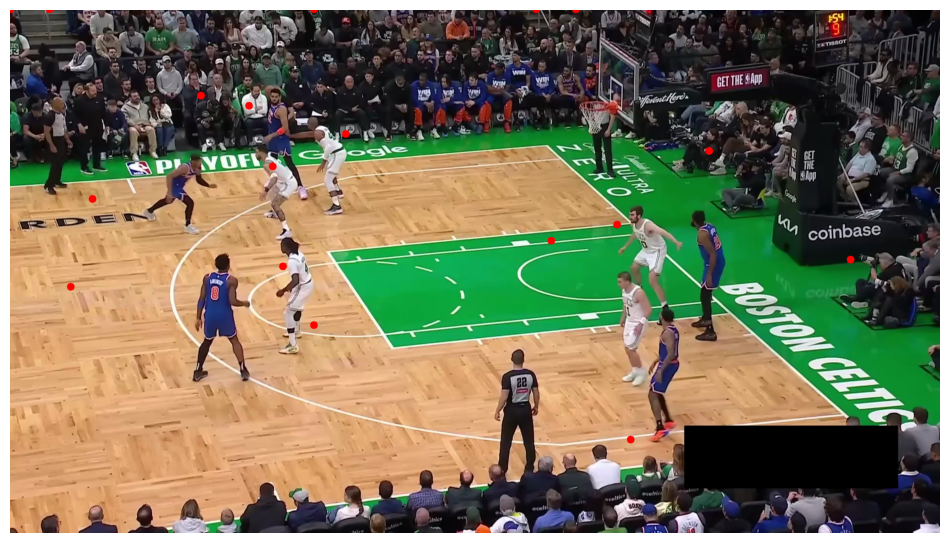

In [18]:
from ultralytics import YOLO
import supervision as sv
import numpy as np

CVM_model = YOLO("runs/pose/runs/CVM/weights/best.pt")

SOURCE_VIDEO_PATH = "Data/boston-celtics-new-york-knicks-game-1-q1-01.54-01.48.mp4"
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = CVM_model.predict(frame, conf=0.5, verbose=False)[0]
key_points = sv.KeyPoints.from_ultralytics(result)

# Keep only keypoints with per-vertex confidence > 0.5
 # Zero out low-confidence keypoints (VertexAnnotator skips (0, 0))
confidence_mask = key_points.confidence > 0.1
filtered_xy = np.where(confidence_mask[..., None], key_points.xy, 0)
key_points = sv.KeyPoints(xy=filtered_xy, confidence=key_points.confidence)

vertex_annotator = sv.VertexAnnotator(color=sv.Color.RED, radius=8)
annotated_frame = vertex_annotator.annotate(scene=frame.copy(), key_points=key_points)
sv.plot_image(annotated_frame)

### Detecting Keypoints with high confidence

## Map Player positions to court coordinates

#### Single frame player positioning mapping

### Full video player position mapping

In [ ]:
# Load the trained best.pt locally with Ultralytics
CVM_model = YOLO("runs/CVM/weights/best.pt")
print(CVM_model)

In [ ]:
KEYPOINT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.3
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID)
KEYPOINT_COLOR = sv.Color.from_hex('#FF1493')

NameError: name 'get_model' is not defined

# 4 shot detection demo (Ilias)

# 5 full pipelinee

# Court Detection 